<a href="https://colab.research.google.com/github/CSI5195-Project/CSI5195-Project/blob/main/SNN_Fraud_Detection_Model2_4_withLIME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

danieldumi_bank_account_fraud_dataset_path = kagglehub.dataset_download('danieldumi/bank-account-fraud-dataset')
danieldumi_model2_3_output_path = kagglehub.dataset_download('danieldumi/model2-3-output')
danieldumi_hyperparameters_path = kagglehub.utility_script_install('danieldumi/hyperparameters')
danieldumi_utils_path = kagglehub.utility_script_install('danieldumi/utils')
danieldumi_modelsnnpc_path = kagglehub.utility_script_install('danieldumi/modelsnnpc')
danieldumi_snn_metrics_path = kagglehub.utility_script_install('danieldumi/snn-metrics')
curiouspotato25_get_best_hyperparams_path = kagglehub.notebook_output_download('curiouspotato25/get-best-hyperparams')
evavivante_snn_metrics_2_path = kagglehub.utility_script_install('evavivante/snn-metrics-2')
evavivante_modelsnnpc_withproba_path = kagglehub.utility_script_install('evavivante/modelsnnpc-withproba')

print('Data source import complete.')


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import json
from datetime import datetime

import hyperparameters
from utils import RandomTrial, read_data

In [ ]:
from modelsnnpc_withproba import *

In [ ]:
DATASET_LIST = ["Variant I"]
# DATASET_LIST = ["Base", "Variant I", "Variant II", "Variant III", "Variant IV", "Variant V"]
NUM_TRIALS = 1
BEGIN_TRIAL = 0
BASE_SEED = 42

METRICS_NAME_GLOBAL = ["accuracy", "precision", "recall", "fpr", "f1_score","auc"]
METRICS_NAME_5FPR = ["accuracy@5FPR","precision@5FPR", "recall@5FPR", "fpr@5FPR", "f1_score@5FPR"]
METRICS_FAIRNESS = ["fpr_ratio_age", "fpr_ratio_income", "fpr_ratio_employment",
                   "eod_age", "eod_income", "eod_employment",
                   "aod_age", "aod_income", "aod_employment"]

with open("/kaggle/input/get-best-hyperparams/model_2_hyperparameters_selected.json", "r") as file:
    HYPERPARAMETERS = json.load(file)[0]

EXPERIMENT_NAME = f"P{HYPERPARAMETERS['population']}-S{HYPERPARAMETERS['step']}-{NUM_TRIALS}trials-begin{BEGIN_TRIAL}"
FIXED_DATE = None

In [ ]:
HYPERPARAMETERS

{'number': 2,
 'values_0': 0.0212644234,
 'values_1': 0.2710215427,
 'datetime_start': '2025-04-05 19:29:48.941809',
 'datetime_complete': '2025-04-05 19:55:16.812815',
 'duration': '0 days 00:25:27.871006',
 'adam_beta1': 0.983,
 'adam_beta2': 0.97,
 'beta1': 0.2116391007,
 'beta2': 0.1585882963,
 'beta3': 0.4339479965,
 'beta4': 0.9383133996,
 'learning_rate': 5.0609e-05,
 'slope': 33,
 'threshold1': 0.2639648969,
 'threshold2': 0.2881911739,
 'threshold3': 0.8150710641,
 'threshold4': 0.3488068823,
 'weight': 0.9887330368,
 'user_attrs_@5FPR accuracy': 0.9582459392,
 'user_attrs_@5FPR aod_age': 0.0212644234,
 'user_attrs_@5FPR aod_employment': 0.0718924364,
 'user_attrs_@5FPR aod_income': 0.0656880803,
 'user_attrs_@5FPR eod_age': 0.0255406848,
 'user_attrs_@5FPR eod_employment': 0.1223113065,
 'user_attrs_@5FPR eod_income': 0.1116794705,
 'user_attrs_@5FPR fnr_ratio_age': 0.9651128051,
 'user_attrs_@5FPR fnr_ratio_employment': 0.8558473887,
 'user_attrs_@5FPR fnr_ratio_income': 0.8

In [ ]:
def dataset_loop(train_dfs, test_dfs, dataset_name, trial_number, seed, path, runs):
    test_dfs[dataset_name].to_csv(f'test_dfs{trial_number}.csv', index=False)
    train_dfs[dataset_name].to_csv(f'train_dfs{trial_number}.csv', index=False)
    x_train = train_dfs[dataset_name].drop(columns=["fraud_bool"])
    y_train = train_dfs[dataset_name]["fraud_bool"]
    x_test = test_dfs[dataset_name].drop(columns=["fraud_bool"])
    y_test = test_dfs[dataset_name]["fraud_bool"]
    num_classes = len(np.unique(y_train))
    num_features = len(x_train.columns)
    class_weights = (1-HYPERPARAMETERS['weight'], HYPERPARAMETERS['weight'])
    model = ModelSNNPC(
        num_features=num_features,
        num_classes=num_classes,
        class_weights=class_weights,
        betas=HYPERPARAMETERS['beta'],
        slope=HYPERPARAMETERS['slope'],
        thresholds=HYPERPARAMETERS['threshold'],
        population=HYPERPARAMETERS['population'],
        batch_size=HYPERPARAMETERS['batch'],
        num_epochs=HYPERPARAMETERS['epoch'],
        num_steps=HYPERPARAMETERS['step'],
        adam_betas=HYPERPARAMETERS['adam_beta'],
        learning_rate=HYPERPARAMETERS['learning_rate'],
        verbose=0
    )
    model.fit(x_train, y_train)
    predictions, targets, proba = model.predict(x_test, y_test)
    np.savetxt(f"predictions_run{trial_number}.csv", predictions, delimiter=",", fmt="%d")
    np.savetxt(f"targets_run{trial_number}.csv", targets, delimiter=",", fmt="%d")
    np.savetxt(f"proba_run{trial_number}.csv", proba, delimiter="\t")
    metrics = model.evaluate(targets, predictions)
    metrics_aequitas = model.evaluate_business_constraint(targets, predictions)
    metrics.update(metrics_aequitas)
    fairness_age = model.evaluate_fairness(x_test, targets, predictions, "customer_age", 50)
    metrics.update({k+"_age": v for k, v in fairness_age.items()})
    fairness_income = model.evaluate_fairness(x_test, targets, predictions, "income", 0.5)
    metrics.update({k+"_income": v for k, v in fairness_income.items()})
    fairness_employement = model.evaluate_fairness(x_test, targets, predictions, "employment_status", 3)
    metrics.update({k+"_employment": v for k, v in fairness_employement.items()})
    results = {}
    results["dataset"] = dataset_name
    results["trial"] = trial_number
    results["seed"] = seed
    for metric in METRICS_NAME_GLOBAL:
        results[metric] = metrics[metric]
    for metric in METRICS_NAME_5FPR:
        results[metric] = metrics_aequitas[metric]
    for metric in METRICS_FAIRNESS:
        results[metric] = metrics[metric]
    csv_row = ','.join([str(x) for x in results.values()])
    with open(path, "a") as f:
        f.write(f"{csv_row}\n")
    prev_runs = runs.get(dataset_name, [])
    prev_runs.append(results)
    print(results)
    runs[dataset_name] = prev_runs
    return runs


In [ ]:
def simulation(datasets, train_dfs, test_dfs, path="./results.csv"):
    np.random.seed(BASE_SEED)
    seeds = np.random.choice(list(range(1_000_000)), size=NUM_TRIALS, replace=False)
    runs = {}
    for trial in range(NUM_TRIALS):
        seed = seeds[trial]
        trial_number = trial
        trial = RandomTrial(seed=seed)
        if trial_number < BEGIN_TRIAL:
            print(f"Skipping trial {trial_number} – seed {seed}")
            continue
        for dataset_name in datasets.keys():
            print(f"Running trial {trial_number} with seed {seed} on dataset {dataset_name}")
            runs = dataset_loop(train_dfs, test_dfs, dataset_name, trial_number, seed, path, runs)
    return runs

In [ ]:
base_path = "/kaggle/input/bank-account-fraud-dataset/"
_, datasets, train_dfs, test_dfs = read_data(base_path, DATASET_LIST)
if not FIXED_DATE:
    date = datetime.now().strftime("%Y%m%d_%H%M%S")
else:
    date = FIXED_DATE
experiment_dir = f"/kaggle/working/results/{date}-{EXPERIMENT_NAME}"
results_path = f"{experiment_dir}/results.csv"
os.makedirs(experiment_dir, exist_ok=True)
if not os.path.exists(results_path):
    with open(results_path, "w") as f:
        f.write("dataset,trial,seed,accuracy,precision,recall,fpr,f1_score,auc,accuracy@5FPR,precision@5FPR,recall@5FPR,fpr@5FPR,f1_score@5FPR,fpr_ratio_age,fpr_ratio_income,fpr_ratio_employment,eod_age,eod_income,eod_employment,aod_age,aod_income,aod_employment\n")

In [ ]:
simulation(datasets, train_dfs, test_dfs, path=results_path)

## LIME

In [ ]:
# LIME
import lime
from lime.lime_tabular import LimeTabularExplainer

#visuals
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
train_df = pd.read_csv('/kaggle/input/model2-3-output/train_dfs0.csv')
train_df

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.6,0.901928,-1,52,40,0.009874,-0.790822,1,1185,...,0,1500.0,0,0,2.890150,0,1,1,0,1
1,0,0.7,0.092673,99,5,20,0.011794,-0.504549,2,3211,...,0,200.0,0,0,17.378022,0,1,2,0,1
2,0,0.3,0.946608,-1,230,20,0.002830,-0.376828,1,778,...,0,1000.0,0,0,5.380868,0,1,1,0,5
3,0,0.1,0.813173,-1,133,20,0.015141,-0.323074,2,1656,...,0,200.0,0,0,8.271832,1,0,1,0,2
4,0,0.8,0.077407,-1,100,20,0.015639,-1.338879,1,1266,...,0,200.0,0,0,4.629884,2,0,1,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794985,0,0.3,0.446860,-1,39,40,0.022443,-1.113637,1,1206,...,0,200.0,0,0,2.386539,3,1,1,0,3
794986,0,0.3,0.219240,15,9,30,0.002655,-0.711915,2,1510,...,0,200.0,0,0,3.697331,2,1,1,0,3
794987,0,0.5,0.857788,-1,44,30,0.010012,-1.009604,2,1686,...,0,200.0,0,0,3.337577,2,1,1,0,3
794988,0,0.6,0.451201,101,13,30,0.006063,-1.120513,2,1626,...,0,1000.0,0,0,2.770652,3,1,1,0,2


In [ ]:
x_train = train_df.drop(columns=["fraud_bool"])
y_train = train_df["fraud_bool"]

In [ ]:
test_df = pd.read_csv('/kaggle/input/model2-3-output/test_dfs0.csv')
test_df

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.4,0.078279,-1,124,50,0.017680,-0.944893,1,1008,...,0,200.0,0,0,2.582348,0,0,1,0,7
1,0,0.8,0.300738,-1,90,30,0.022969,-1.381405,1,2822,...,0,1000.0,0,0,22.242468,2,1,1,0,6
2,0,0.9,0.858890,-1,118,50,0.033415,-1.660269,1,461,...,1,1500.0,0,0,4.185217,3,0,1,0,7
3,0,0.1,0.996272,-1,46,40,0.011640,26.131787,0,660,...,0,500.0,0,0,11.437373,2,1,1,0,6
4,0,0.9,0.744787,28,8,10,0.023257,-0.197556,3,931,...,0,200.0,0,0,7.925004,2,1,1,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205005,0,0.1,0.905769,-1,174,70,0.024419,51.101061,0,1690,...,1,1500.0,0,0,3.805816,0,1,1,0,6
205006,0,0.9,0.187163,-1,40,30,1.093254,48.431776,0,2149,...,0,500.0,0,0,10.988173,3,1,1,0,6
205007,0,0.8,0.581199,-1,119,40,0.014694,-0.433292,1,1060,...,0,200.0,0,0,2.253453,2,1,1,0,7
205008,0,0.9,0.684417,-1,123,30,0.015518,-0.782858,1,1160,...,1,1000.0,0,0,1.090393,0,1,1,0,7


In [ ]:
x_test = test_df.drop(columns=["fraud_bool"])
y_test = test_df["fraud_bool"]

In [ ]:
def get_trained_model(x_train, y_train):

    num_classes = len(np.unique(y_train))
    num_features = len(x_train.columns)
    class_weights = (1-HYPERPARAMETERS['weight'], HYPERPARAMETERS['weight'])
    model = ModelSNNPC(
        num_features=num_features,
        num_classes=num_classes,
        class_weights=class_weights,
        betas=HYPERPARAMETERS['beta'],
        slope=HYPERPARAMETERS['slope'],
        thresholds=HYPERPARAMETERS['threshold'],
        population=HYPERPARAMETERS['population'],
        batch_size=HYPERPARAMETERS['batch'],
        num_epochs=HYPERPARAMETERS['epoch'],
        num_steps=HYPERPARAMETERS['step'],
        adam_betas=HYPERPARAMETERS['adam_beta'],
        learning_rate=HYPERPARAMETERS['learning_rate'],
        verbose=0
    )
    model.fit(x_train, y_train)
    return model

In [ ]:
model = get_trained_model(x_train, y_train)

In [ ]:
explainer = LimeTabularExplainer(
    training_data=x_train.values,
    feature_names=x_train.columns.tolist(),
    class_names=['Not Fraud', 'Fraud'],
    mode='classification'
)

In [ ]:
def dummy_predict(x):
    predictions, targets, proba = model.predict(pd.DataFrame(x),y_test.iloc[:len(x)])
    return np.array(proba)

In [ ]:
feature_importance = []
for i in range(1000):
    explanation = explainer.explain_instance(
        data_row=x_test.iloc[i],
        predict_fn=dummy_predict,
        num_features=31
    )
    local_importance = explanation.as_map()
    feature_importance.append(local_importance)

In [ ]:
feature_importance_dfs = []
for i in range(len(feature_importance)):
    feature_importance_df = pd.DataFrame(feature_importance[i][1])
    feature_importance_df.columns = ['Feature Index','Score']
    feature_importance_df.index = feature_importance_df['Feature Index']
    feature_importance_df = feature_importance_df.sort_index()
    feature_importance_df = feature_importance_df.drop(['Feature Index'],axis=1)
    feature_importance_dfs.append(feature_importance_df)

In [ ]:
all_feature_importance_df = pd.concat(feature_importance_dfs,axis=1)
all_feature_importance_df.to_csv('all_feature_importance_model2_df.csv')
all_feature_importance_df

,Score,Score,Score,Score,Score,Score,Score,Score,Score,Score,...,Score,Score,Score,Score,Score,Score,Score,Score,Score,Score
Feature Index,,,,,,,,,,,,,,,,,,,,,
0,0.001350,0.002093,-0.002109,-0.007696,0.001072,-0.004563,0.002787,0.006437,-0.007317,0.002282,...,0.000461,-0.005760,0.008664,0.004668,0.002830,-0.009369,-0.007674,-0.006198,-0.005194,-0.000920
1,0.008366,0.008756,-0.006029,-0.006358,-0.007780,-0.002450,-0.006431,0.009200,-0.010591,0.006695,...,0.005180,0.010876,-0.004967,0.008357,0.007265,-0.010758,0.007247,-0.020961,0.019177,0.006639
2,0.144806,0.143326,0.128339,0.133371,-0.127494,0.140516,-0.100724,0.143536,-0.130321,0.135559,...,0.131433,0.145244,0.131931,0.139481,0.137691,0.136151,-0.118586,-0.121806,0.132739,-0.123911
3,0.013779,0.010864,0.008532,0.001372,-0.008242,0.006893,-0.016411,-0.003163,-0.015391,0.005448,...,0.002794,0.006974,0.014737,0.020706,0.017612,0.013426,-0.004424,-0.000742,0.001977,-0.003777
4,0.009434,0.001942,0.006956,0.010150,-0.023056,-0.017760,-0.017602,0.010976,0.007414,-0.003351,...,0.010871,0.006844,0.019172,-0.004076,-0.001333,-0.012627,0.000046,-0.015587,0.009448,-0.006768
5,-0.001639,-0.000062,0.014732,-0.006668,-0.000157,0.022600,-0.000298,-0.004769,-0.002361,-0.010294,...,-0.006435,0.000475,-0.004259,-0.017976,0.003901,0.000233,0.011175,-0.010636,-0.001672,-0.004053
6,0.029650,0.036981,0.029291,-0.057066,-0.011497,-0.010128,0.030567,0.032154,0.038003,0.027734,...,0.033303,0.038862,-0.051075,-0.060926,0.028603,0.030597,0.024335,-0.022420,-0.050474,-0.008144
7,-0.005256,-0.002203,0.002673,-0.014301,0.024937,0.000274,0.008154,-0.006923,-0.002790,0.008241,...,0.013497,0.000467,-0.011350,-0.016592,0.003745,-0.001104,0.004276,-0.000243,-0.013102,-0.016367
8,-0.004311,0.003582,0.011926,-0.001702,-0.000449,0.003825,-0.012238,0.003838,-0.010266,-0.005611,...,-0.008004,-0.000963,0.009030,-0.005441,-0.005473,-0.001912,0.001073,0.005855,0.002534,0.001810


In [ ]:
all_feature_importance_df['Average'] = all_feature_importance_df.mean(axis=1)
all_feature_importance_df.sort_values(by='Average',ascending=False)

,Score,Score,Score,Score,Score,Score,Score,Score,Score,Score,...,Score,Score,Score,Score,Score,Score,Score,Score,Average,Absolute Value Average
Feature Index,,,,,,,,,,,,,,,,,,,,,
21,0.092235,0.091772,-0.099871,0.110001,0.109122,0.094304,0.099202,-0.099742,0.107753,0.105420,...,0.104308,-0.100413,0.095112,0.094936,0.094194,0.088456,-0.097389,-0.092480,5.948760e-02,5.948760e-02
2,0.144806,0.143326,0.128339,0.133371,-0.127494,0.140516,-0.100724,0.143536,-0.130321,0.135559,...,0.131931,0.139481,0.137691,0.136151,-0.118586,-0.121806,0.132739,-0.123911,5.573868e-02,5.573868e-02
14,-0.018671,0.042211,0.038165,-0.050092,0.040791,0.036371,0.042635,-0.022669,0.040940,0.035444,...,-0.012509,0.042051,0.049890,0.035370,0.044027,0.042121,-0.015440,-0.029339,2.481875e-02,2.481875e-02
18,-0.092339,0.104037,0.097508,-0.102954,0.094833,0.095287,0.098287,-0.102206,0.099766,-0.107940,...,0.094379,0.088929,0.095475,0.099581,0.107354,-0.096239,-0.101836,-0.099969,1.012306e-02,1.012306e-02
17,0.024467,-0.000856,0.001709,0.026800,-0.035657,0.030739,0.006797,-0.007002,0.024148,0.030711,...,0.025978,0.027106,0.019945,-0.029060,-0.032464,0.034269,0.023967,0.003256,5.503398e-03,5.503398e-03
9,0.002712,0.004634,0.008925,0.001398,0.011115,0.009411,0.014289,0.001589,0.000608,0.004799,...,-0.004750,-0.011796,-0.000780,0.000353,0.005222,0.006277,0.007096,0.002874,3.512217e-03,3.512217e-03
6,0.029650,0.036981,0.029291,-0.057066,-0.011497,-0.010128,0.030567,0.032154,0.038003,0.027734,...,-0.051075,-0.060926,0.028603,0.030597,0.024335,-0.022420,-0.050474,-0.008144,3.333462e-03,3.333462e-03
15,-0.004685,0.002175,0.009338,-0.005542,0.003087,0.001770,0.006497,0.002930,0.005426,0.009972,...,0.009478,0.003836,-0.017393,0.002632,0.002034,0.004948,0.003212,0.005158,2.613959e-03,2.613959e-03
11,0.008925,-0.003324,0.013781,0.006281,0.005000,0.002687,0.003185,0.003953,-0.002700,-0.001779,...,0.013601,0.000274,0.002595,0.008516,0.000530,-0.003190,-0.005981,0.012081,1.807230e-03,1.807230e-03


In [ ]:
all_feature_importance_df['Absolute Value Average 2'] = all_feature_importance_df.abs().mean(axis=1)

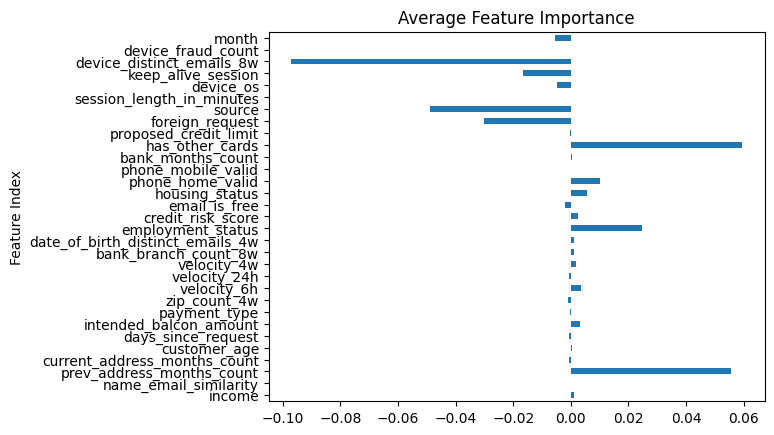

In [ ]:
# Plotting the bar chart
ax = all_feature_importance_df['Average'].plot(kind='barh', title='Average Feature Importance')

ax.set_yticklabels(x_train.columns.tolist(), ha='right')

# Show the plot
plt.show()

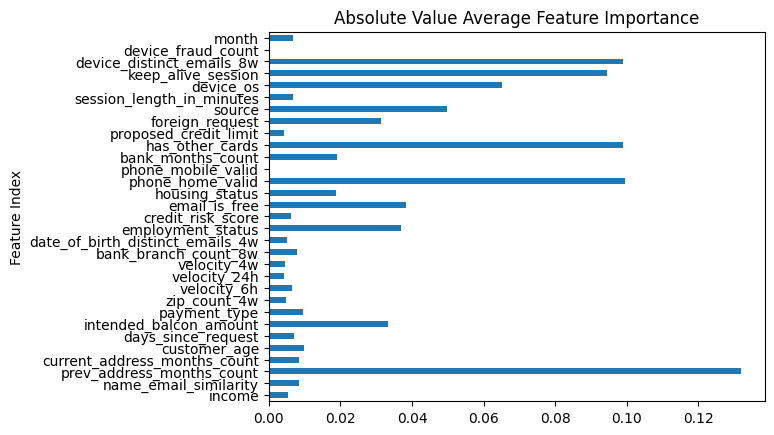

In [ ]:
ax = all_feature_importance_df['Absolute Value Average 2'].plot(kind='barh', title='Absolute Value Average Feature Importance')

# Setting custom x-axis labels
ax.set_yticklabels(x_train.columns.tolist(), ha='right')  # Customize rotation and alignment

# Show the plot
plt.show()

In [ ]:
# Local Explainability
explanation = explainer.explain_instance(
    data_row=x_test.iloc[0],
    predict_fn=dummy_predict,
    num_features=31
)
explanation.show_in_notebook()